## Ensemble Technique
Use the final project from ARTI 300 as your starting point.  Then insert the following steps.

In [1]:
#!pip install xgboost

In [2]:
# Make sure you have all the libraries that we will be using
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
#To install xgboost library use - !pip install xgboost 
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

C:\Users\codyd\AppData\Local\Temp\ipykernel_19428\3736186166.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### After your Univariate Analysis but before your Feature engineering we need to do a Bivariate Analysis


In [3]:
df = pd.read_csv("job_candidates.csv")

In [4]:
df = df.drop(['enrollee_id'], axis=1)
df = df.drop(['city'], axis=1)

In [5]:
for i in range(len(list(df.columns.values))):
    data = df[df.isnull().sum(axis=1) == i]
    print(f"Number of rows with {i} missing value(s): {len(data.index)}")

Number of rows with 0 missing value(s): 8955
Number of rows with 1 missing value(s): 3718
Number of rows with 2 missing value(s): 3654
Number of rows with 3 missing value(s): 1953
Number of rows with 4 missing value(s): 628
Number of rows with 5 missing value(s): 176
Number of rows with 6 missing value(s): 62
Number of rows with 7 missing value(s): 12
Number of rows with 8 missing value(s): 0
Number of rows with 9 missing value(s): 0
Number of rows with 10 missing value(s): 0
Number of rows with 11 missing value(s): 0


In [6]:
data = df[df.isnull().sum(axis=1) == 7]
data.head(20)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1376,0.920,NaN,Has relevent experience,NaN,NaN,NaN,6,NaN,NaN,NaN,156,0.0
2518,0.897,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,222,0.0
7746,0.624,NaN,No relevent experience,NaN,NaN,NaN,5,NaN,NaN,NaN,98,0.0
8905,0.925,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,53,0.0
9206,0.920,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,138,0.0
10337,0.887,NaN,No relevent experience,NaN,NaN,NaN,>20,NaN,NaN,NaN,39,1.0
11789,0.897,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,22,0.0
12079,0.698,NaN,No relevent experience,NaN,NaN,NaN,2,NaN,NaN,NaN,97,0.0
12348,0.920,NaN,No relevent experience,NaN,NaN,NaN,<1,NaN,NaN,NaN,43,0.0
13236,0.920,NaN,Has relevent experience,NaN,NaN,NaN,>20,NaN,NaN,NaN,21,0.0


In [7]:
df = df[df.isnull().sum(axis=1) <= 4]
df.shape

(18908, 12)

In [8]:
df.loc[df.gender.isnull(), 'gender'] = "Unknown"

In [9]:
df.shape

(18908, 12)

In [10]:
df.loc[df.enrolled_university.isnull(), 'enrolled_university'] = 'no_enrollment'

In [11]:
df.loc[df.education_level.isnull(), 'education_level'] = 'Graduate'

In [12]:
df.loc[df.major_discipline.isnull(), 'major_discipline'] = "Unknown"

In [13]:
df.loc[df.experience.isnull(), 'experience'] = '>20'

In [14]:
df = df.drop('company_size', axis=1)

In [15]:
df = df.drop('company_type', axis=1)

In [16]:
df.loc[df.last_new_job.isnull(), 'last_new_job'] = '1'

In [17]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [18]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    data[feature].describe()
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [19]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [20]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Categorical Features:
<ul>
    <li>gender</li>
    <li>relevent_experience</li>
    <li>enrolled_university</li>
    <li>education_level</li>
    <li>major_discipline</li>
    <li>experience</li>
    <li>last_new_job</li>
</ul>

<b>gender</b>

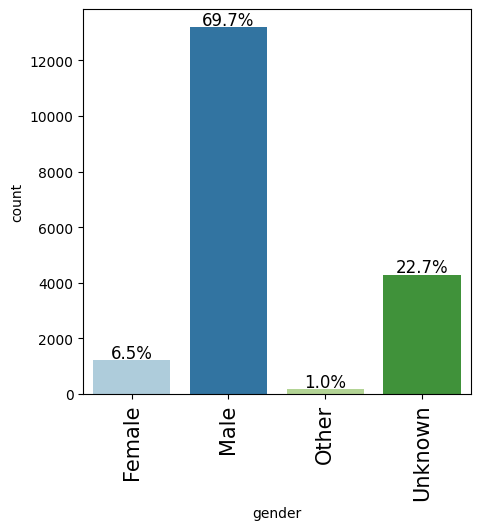

In [21]:
labeled_barplot(df, 'gender', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Vast majority of candidates were male</li>
    <li>Gender was more than three times as likely to be Unknown than Female</li>
</ul>

<b>relevent_experience</b>

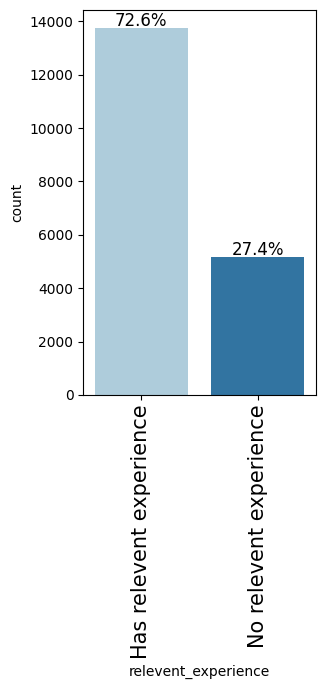

In [22]:
labeled_barplot(df, 'relevent_experience', perc=True)

<b>Observation(s):</b>
<ul>
    <li>More candidates had relevant experience</li>
</ul>

<b>enrolled_university</b>

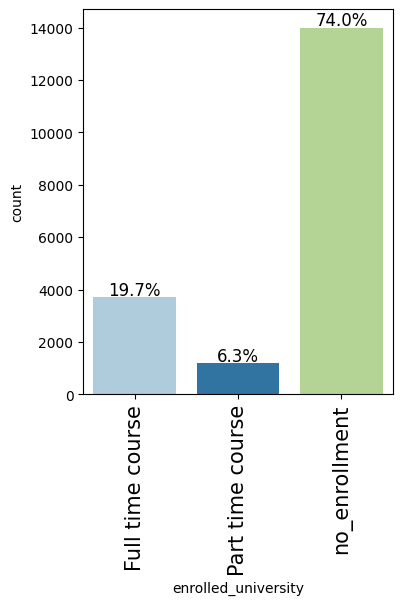

In [23]:
labeled_barplot(df, 'enrolled_university', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates were not enrolled</li>
    <li>More candidates were enrolled full-time than part-time</li>
</ul>

<b>education_level</b>

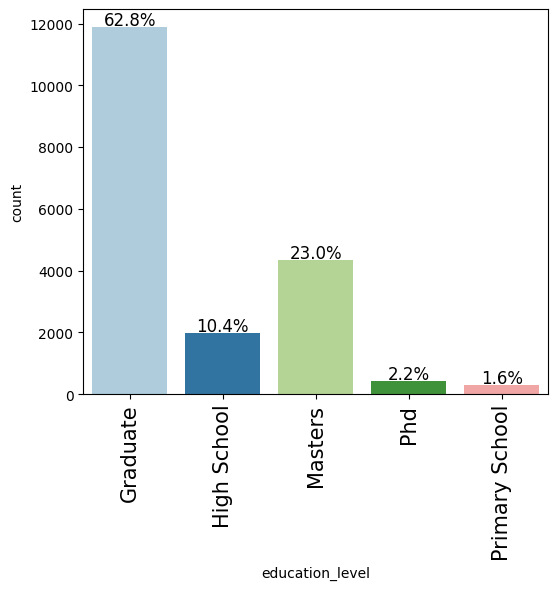

In [24]:
labeled_barplot(df, 'education_level', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates were college graduates</li>
    <li>Masters > high school > phd > primary school</li>
</ul>

<b>major_discipline</b>

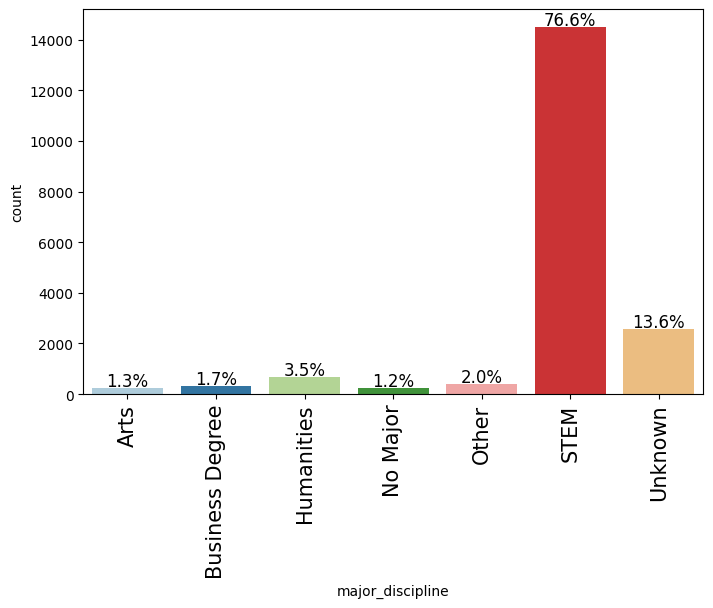

In [25]:
labeled_barplot(df, 'major_discipline', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Vast majority of candidates were in STEM</li>
    <li>Others are similarly frequent, aside from unknown</li>
</ul>

<b>experience</b>

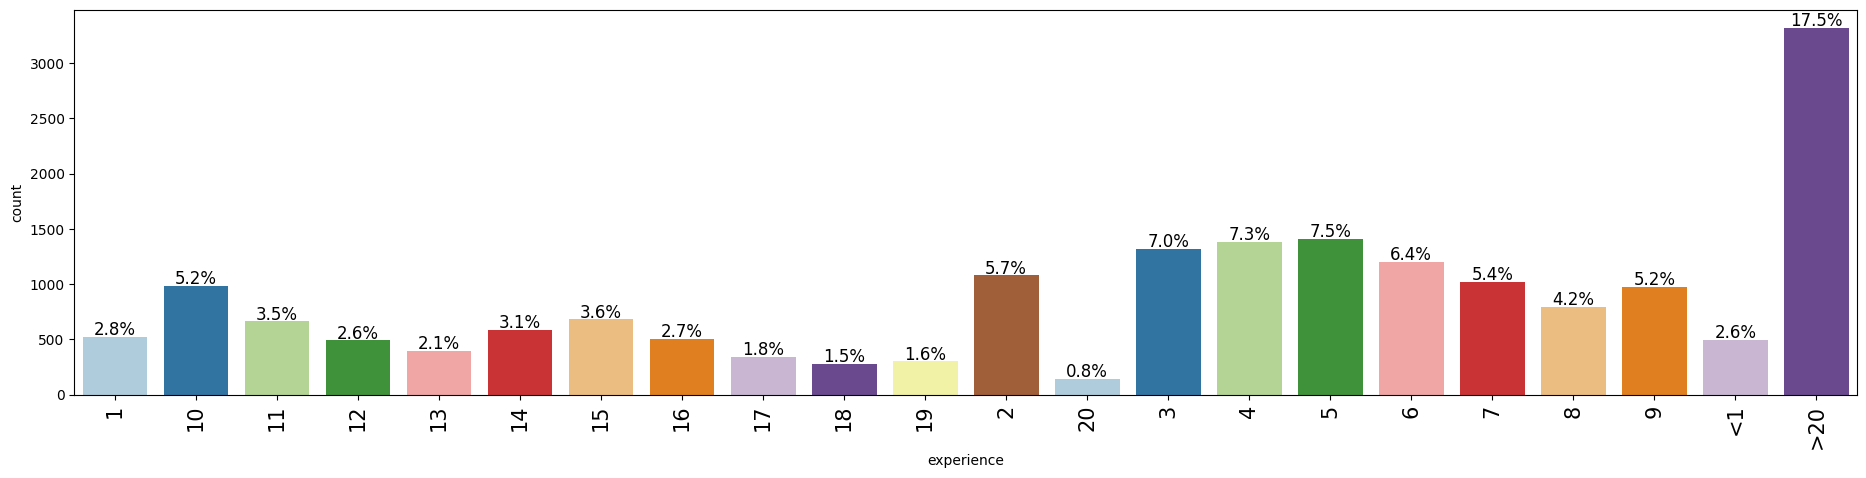

In [26]:
labeled_barplot(df, 'experience', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates had more than 20 years of experience</li>
    <li>Lowest count of experience was exactly 20 years</li>
</ul>

<b>last_new_job</b>

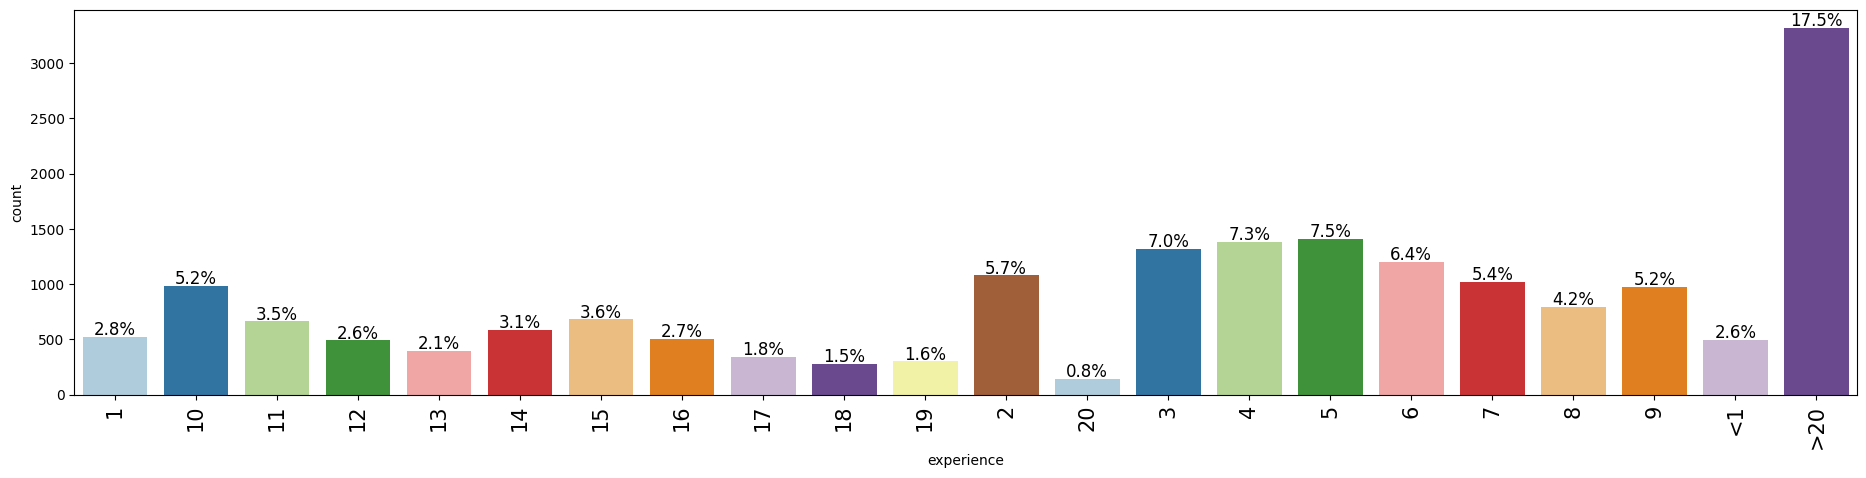

In [27]:
labeled_barplot(df, 'experience', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates are a year apart from their previous job</li>
    <li>2, >4, and never were similarly likely</li>
    <li>3 and 4 are equally likely</li>
</ul>

#### Numerical Features:
<ul>
    <li>city_development_index</li>
    <li>training_hours</li>
</ul>

<b>city_development_index</b>

In [28]:
df['city_development_index'].describe()

count    18908.000000
mean         0.829421
std          0.123049
min          0.448000
25%          0.740000
50%          0.910000
75%          0.920000
max          0.949000
Name: city_development_index, dtype: float64

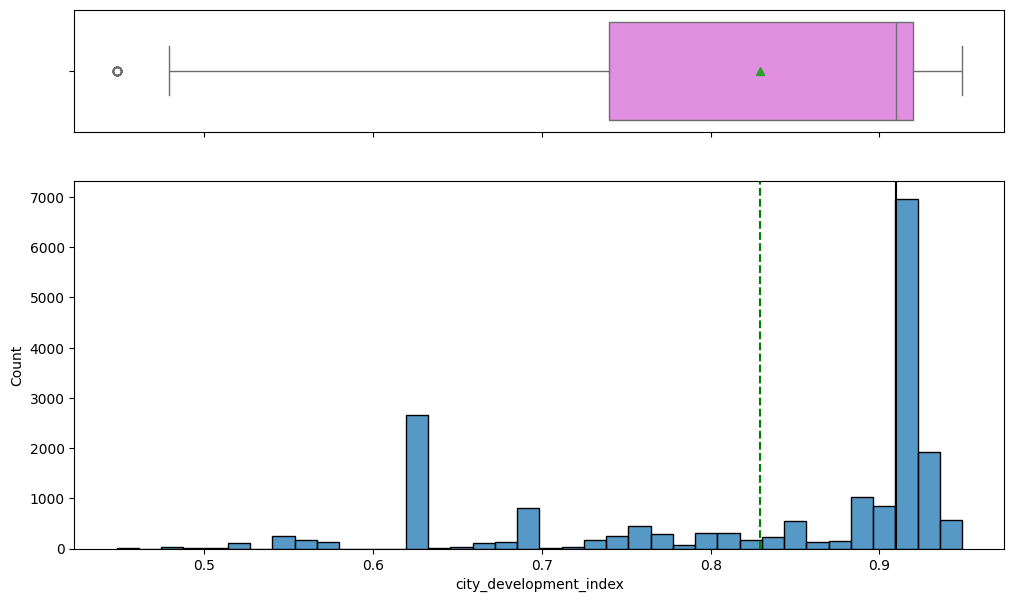

In [29]:
histogram_boxplot(df, 'city_development_index');

<b>Observation(s):</b>
<ul>
    <li>Largest cluster just above 0.9</li>
    <li>Data will need to be normalized, due to erratic distribution</li>
</ul>

<b>training_hours</b>

In [30]:
df['training_hours'].describe()

count    18908.000000
mean        65.379945
std         60.065504
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

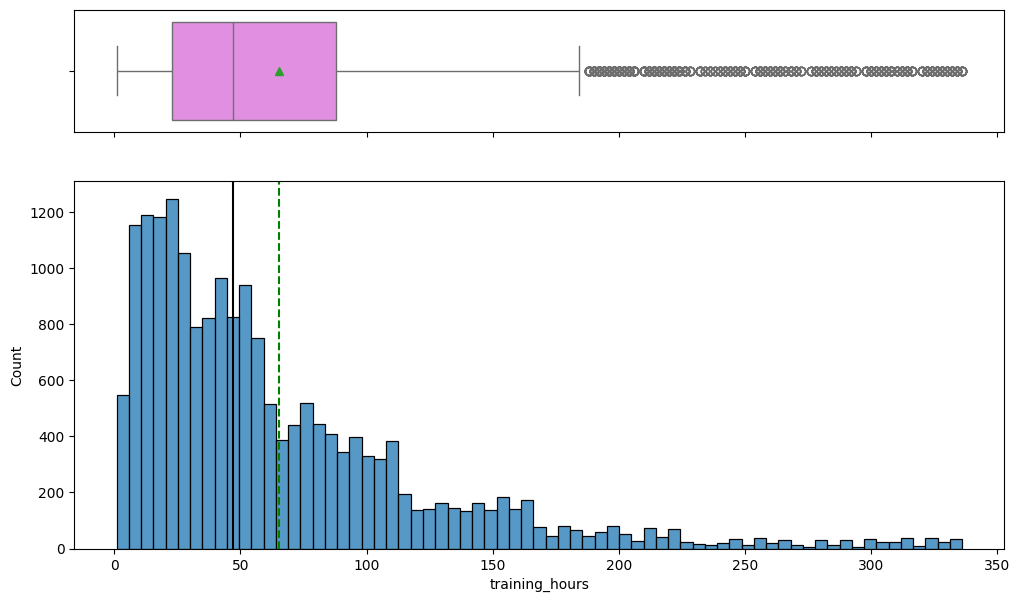

In [31]:
histogram_boxplot(df, 'training_hours');

<b>Observation(s):</b>
<ul>
    <li>Distribution heavily skewed right</li>
    <li>Largest cluster around 25</li>
    <li>Decline in count is very gradual after 125</li>
</ul>

### Multivariate Analysis

<b>target x gender</b>

target     0.0   1.0    All
gender                     
All      14190  4718  18908
Male     10177  3008  13185
Unknown   2965  1335   4300
Female     911   326   1237
Other      137    49    186
------------------------------------------------------------------------------------------------------------------------


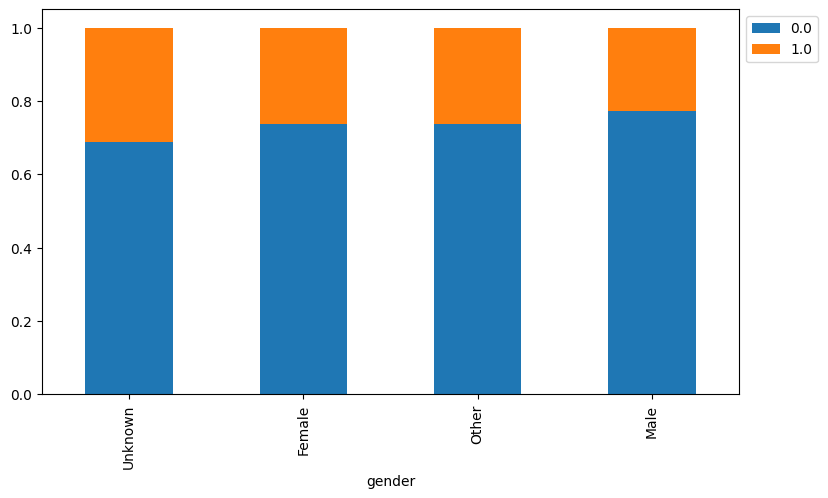

In [32]:
stacked_barplot(df, 'gender', 'target')

<b>Observation(s):</b>
<ul>
    <li>There is no considerable difference between the unique values.</li>
</ul>

<b>target x relevent_experience</b>

target                     0.0   1.0    All
relevent_experience                        
All                      14190  4718  18908
Has relevent experience  10794  2940  13734
No relevent experience    3396  1778   5174
------------------------------------------------------------------------------------------------------------------------


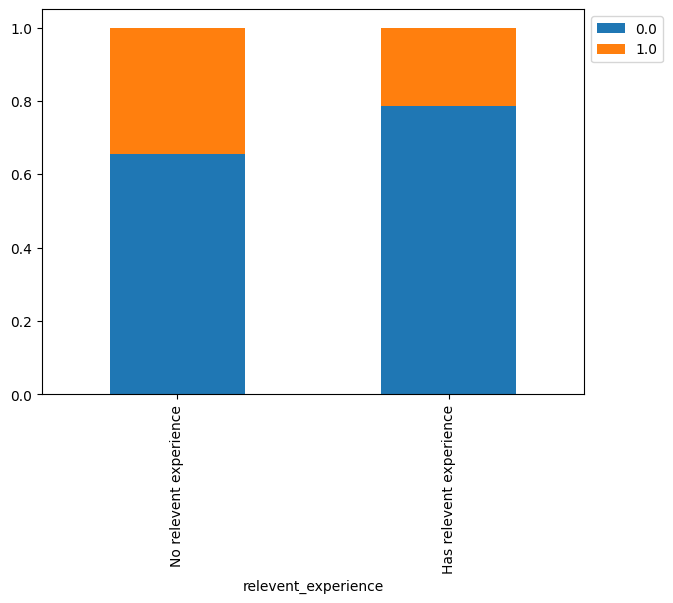

In [33]:
stacked_barplot(df, 'relevent_experience', 'target')

<b>Observation(s):</b>
<ul>
    <li>Candidates with no relevant experience were slightly more likey to desire the new job</li>
</ul>

<b>target x enrolled_university</b>

target                 0.0   1.0    All
enrolled_university                    
All                  14190  4718  18908
no_enrollment        10998  3002  14000
Full time course      2301  1418   3719
Part time course       891   298   1189
------------------------------------------------------------------------------------------------------------------------


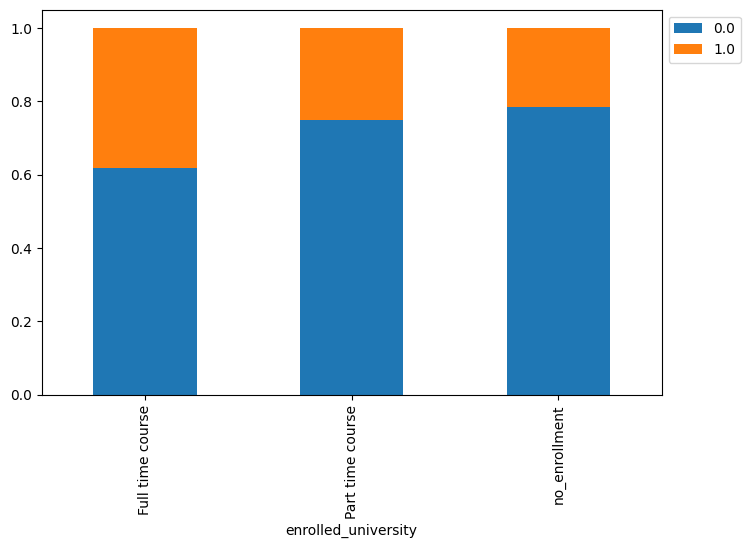

In [34]:
stacked_barplot(df, 'enrolled_university', 'target')

<b>Observation(s):</b>
<ul>
    <li>Candidates enrolled full time were most likely to desire the new job</li>
    <li>Candidates enrolled part time and not enrolled at all were equally likely</li>
</ul>

<b>target x education_level</b>

target             0.0   1.0    All
education_level                    
All              14190  4718  18908
Graduate          8571  3304  11875
Masters           3423   934   4357
High School       1580   383   1963
Phd                355    58    413
Primary School     261    39    300
------------------------------------------------------------------------------------------------------------------------


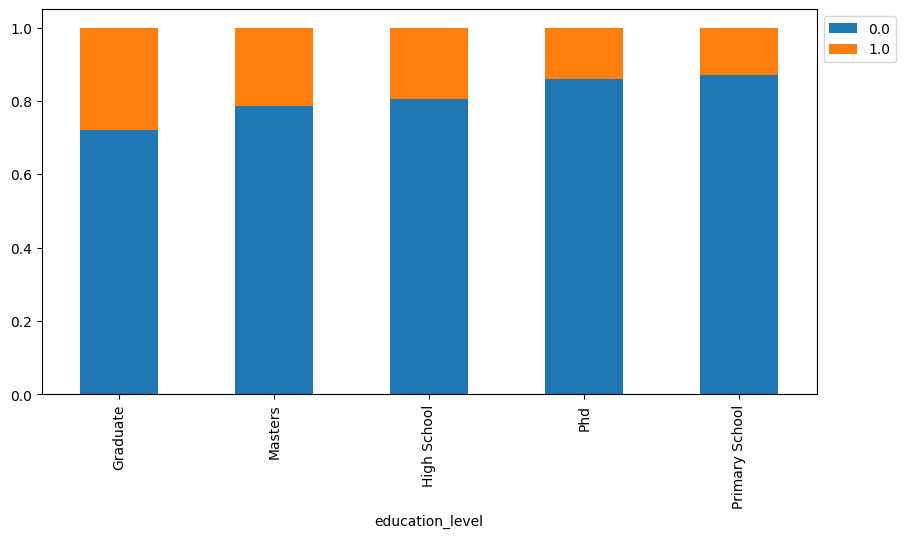

In [35]:
stacked_barplot(df, 'education_level', 'target')

<b>Observation(s):</b>
<ul>
    <li>College graduates were most likely to desire the new job, by a small margin</li>
    <li>All other values were roughly equal in likelihood</li>
</ul>

<b>target x major_discipline</b>

target              0.0   1.0    All
major_discipline                    
All               14190  4718  18908
STEM              10695  3788  14483
Unknown            2079   493   2572
Humanities          528   141    669
Other               279   102    381
Business Degree     241    86    327
No Major            168    55    223
Arts                200    53    253
------------------------------------------------------------------------------------------------------------------------


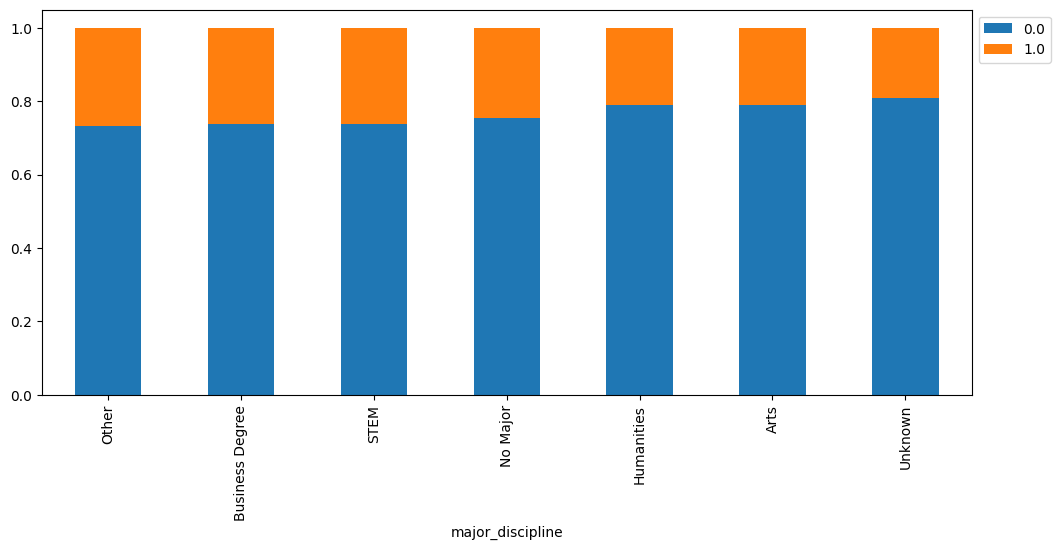

In [36]:
stacked_barplot(df, 'major_discipline', 'target')

<b>Observation(s):</b>
<ul>
    <li>There is no considerable difference between the unique values.</li>
</ul>

<b>target x experience</b>

target        0.0   1.0    All
experience                    
All         14190  4718  18908
>20          2799   516   3315
3             853   468   1321
4             929   452   1381
5            1004   407   1411
2             716   364   1080
6             864   340   1204
7             720   303   1023
<1            266   232    498
1             300   226    526
9             763   213    976
10            778   207    985
8             600   195    795
11            511   151    662
15            569   114    683
14            479   107    586
12            399    92    491
13            321    77    398
16            434    71    505
17            284    57    341
19            251    52    303
18            237    41    278
20            113    33    146
------------------------------------------------------------------------------------------------------------------------


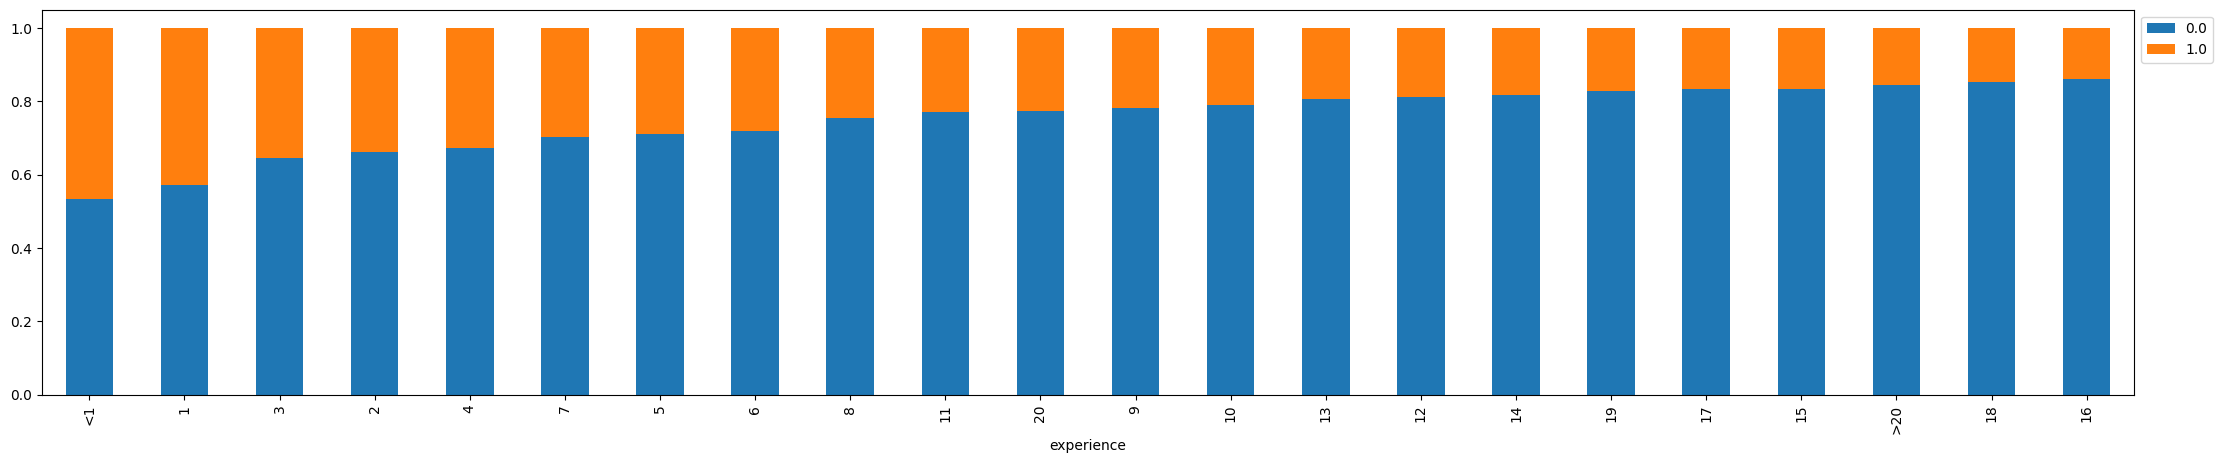

In [37]:
stacked_barplot(df, 'experience', 'target')

<b>Observation(s):</b>
<ul>
    <li>Roughly, the more years of experience the candidate had, the less likely they were to desire the new job</li>
</ul>

<b>target x last_new_job</b>

target          0.0   1.0    All
last_new_job                    
All           14190  4718  18908
1              6096  2243   8339
never          1628   723   2351
2              2192   698   2890
>4             2683   596   3279
3               790   231   1021
4               801   227   1028
------------------------------------------------------------------------------------------------------------------------


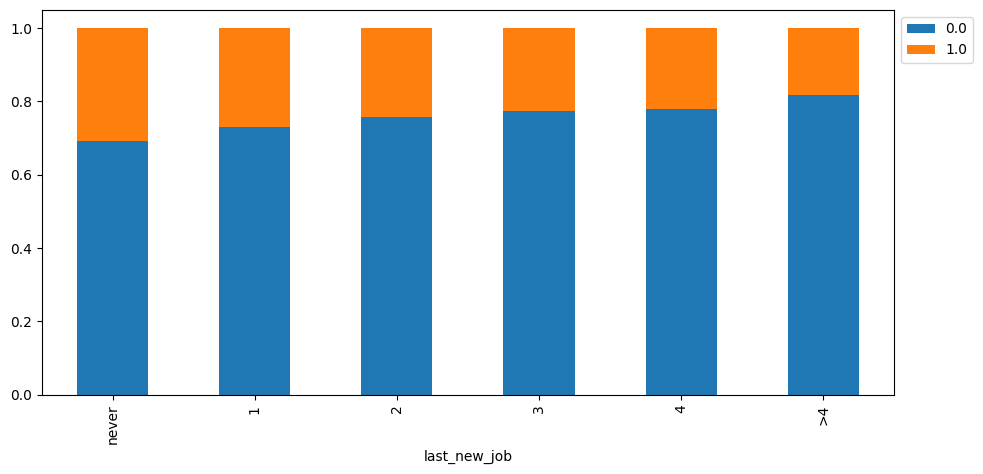

In [38]:
stacked_barplot(df, 'last_new_job', 'target')

<b>Observation(s):</b>
<ul>
    <li>The more years since their last job, the less likely they were to desire the new one</li>
</ul>

<b>target x city_development_index</b>

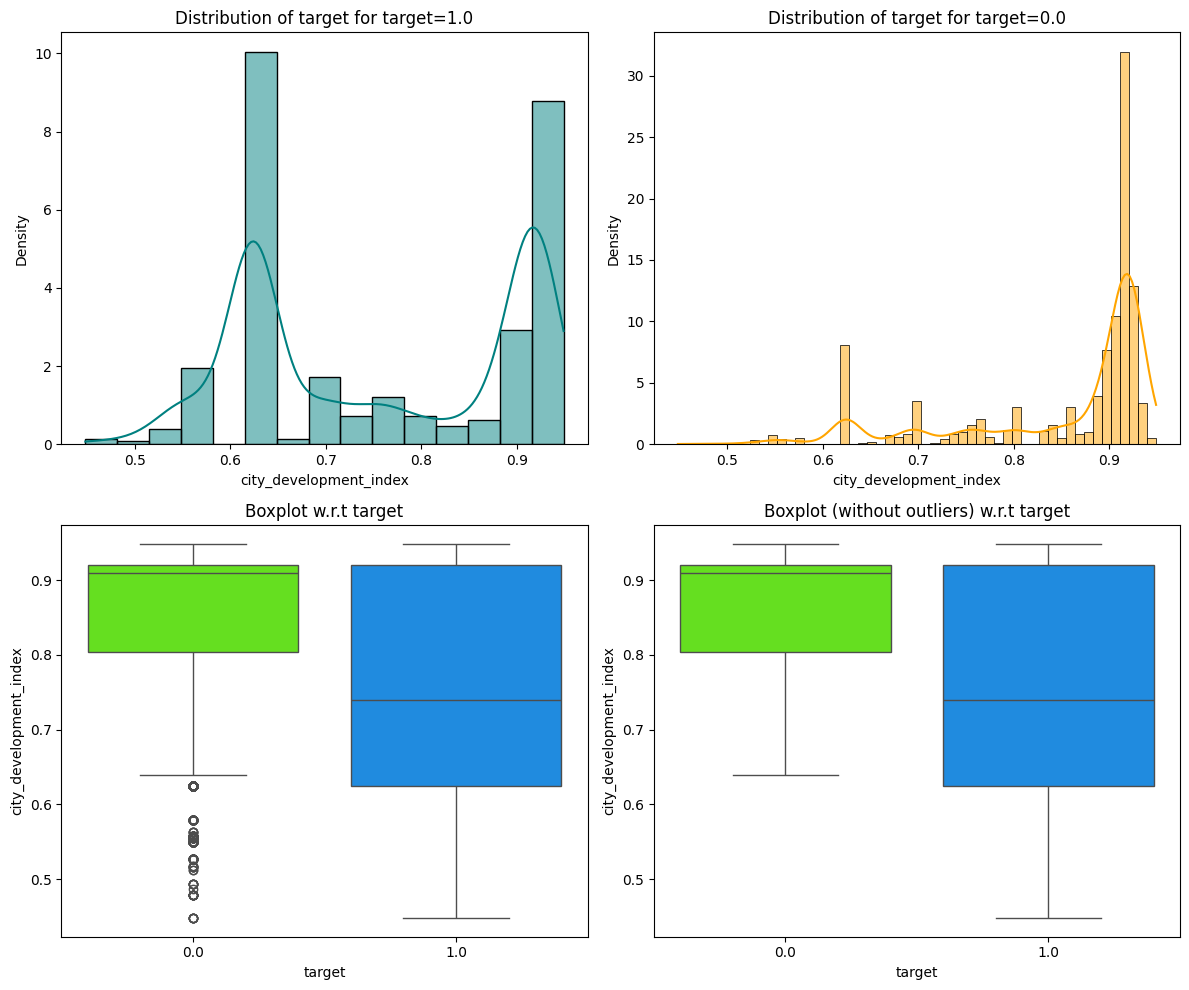

In [39]:
distribution_plot_wrt_target(df, 'city_development_index', 'target')

<b>Observation(s):</b>
<ul>
    <li>On average, candidates interested in the new job had a lower city_development_index</li>
</ul>

<b>target x training_hours</b>

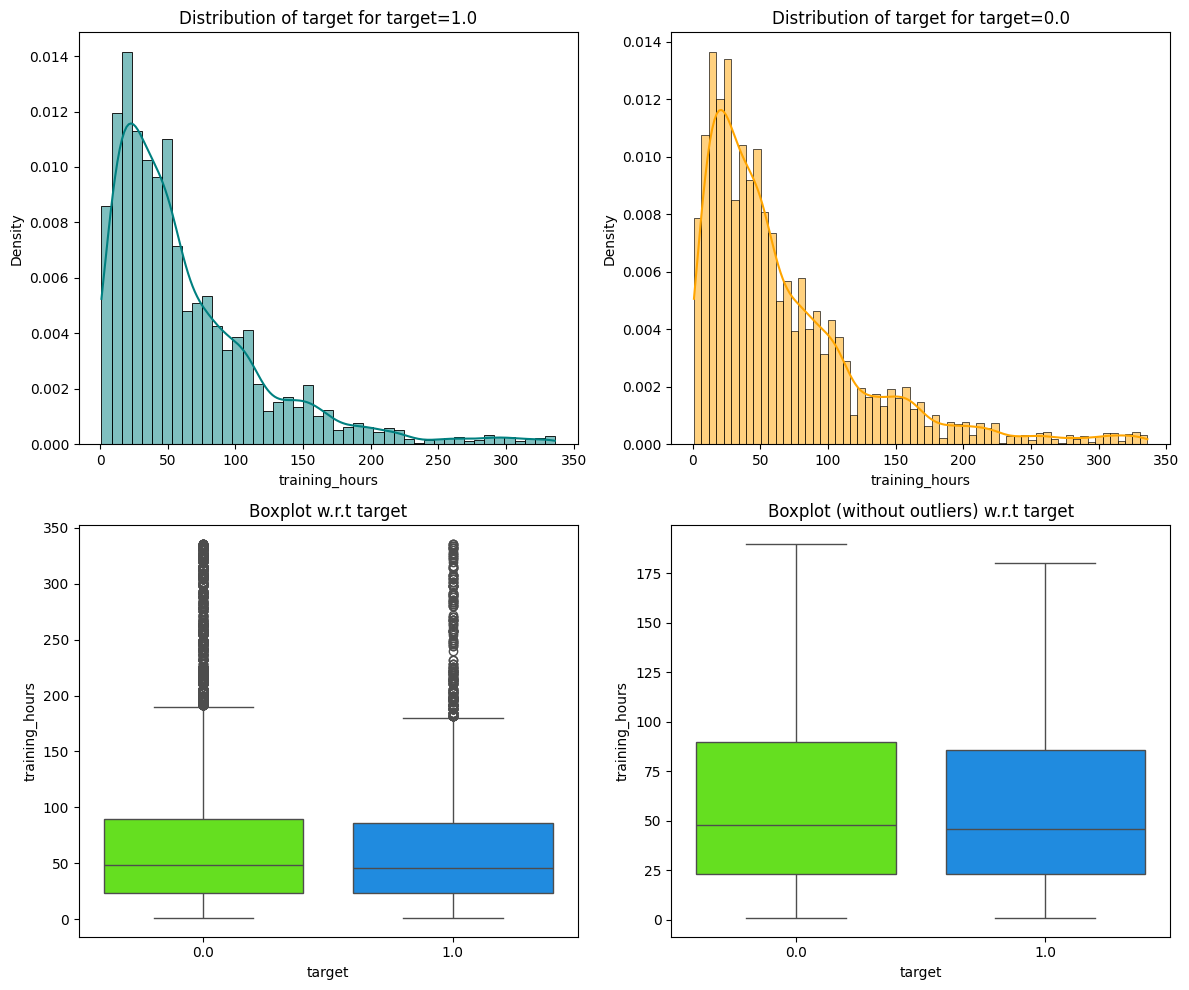

In [40]:
distribution_plot_wrt_target(df, 'training_hours', 'target')

<b>Observation(s):</b>
<ul>
    <li>There does not appear to be a considerable difference.</li>
</ul>

### now insert your feature engineering code from ARTI 300

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['education_level'] = label_encoder.fit_transform(df['education_level'])

In [42]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [43]:
df = pd.get_dummies(df, columns=['relevent_experience'], drop_first=True)

In [44]:
df = pd.get_dummies(df, columns=['enrolled_university'], drop_first=True)

In [45]:
df['major_discipline'] = label_encoder.fit_transform(df['major_discipline'])

In [46]:
df['experience'] = label_encoder.fit_transform(df['experience'])

In [47]:
df['last_new_job'] = label_encoder.fit_transform(df['last_new_job'])

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['city_development_index']])
df[['city_development_index']] = scaler.transform(df[['city_development_index']])

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['training_hours']])
df[['training_hours']] = scaler.transform(df[['training_hours']])

In [50]:
df.corr()

,city_development_index,education_level,major_discipline,experience,last_new_job,training_hours,target,gender_Male,gender_Other,gender_Unknown,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment
city_development_index,1.000000,0.070409,-0.097980,0.034627,0.024136,0.002488,-0.340425,0.119295,0.031761,-0.157584,-0.055880,-0.019073,0.157385
education_level,0.070409,1.000000,0.102727,0.017585,0.074465,-0.013239,-0.084765,-0.021595,-0.003236,0.018874,0.067429,-0.039051,0.072397
major_discipline,-0.097980,0.102727,1.000000,-0.005279,0.063991,0.007983,-0.005056,0.024897,-0.006668,0.026787,0.082376,0.022178,-0.138275
experience,0.034627,0.017585,-0.005279,1.000000,0.062314,-0.004632,-0.006187,0.007049,-0.007211,-0.001465,-0.008061,-0.025143,0.028135
last_new_job,0.024136,0.074465,0.063991,0.062314,1.000000,-0.008902,-0.023210,0.037390,0.004305,-0.025138,0.168601,-0.054254,0.016870
training_hours,0.002488,-0.013239,0.007983,-0.004632,-0.008902,1.000000,-0.022253,-0.001166,-0.003450,0.001351,-0.012278,0.009091,0.000271
target,-0.340425,-0.084765,-0.005056,-0.006187,-0.023210,-0.022253,1.000000,-0.075012,0.003206,0.076405,0.133493,0.000663,-0.136974
gender_Male,0.119295,-0.021595,0.024897,0.007049,0.037390,-0.001166,-0.075012,1.000000,-0.151289,-0.823507,-0.095269,-0.015705,0.083101
gender_Other,0.031761,-0.003236,-0.006668,-0.007211,0.004305,-0.003450,0.003206,-0.151289,1.000000,-0.054078,0.034981,0.013915,-0.021659
gender_Unknown,-0.157584,0.018874,0.026787,-0.001465,-0.025138,0.001351,0.076405,-0.823507,-0.054078,1.000000,0.088397,0.020583,-0.097519


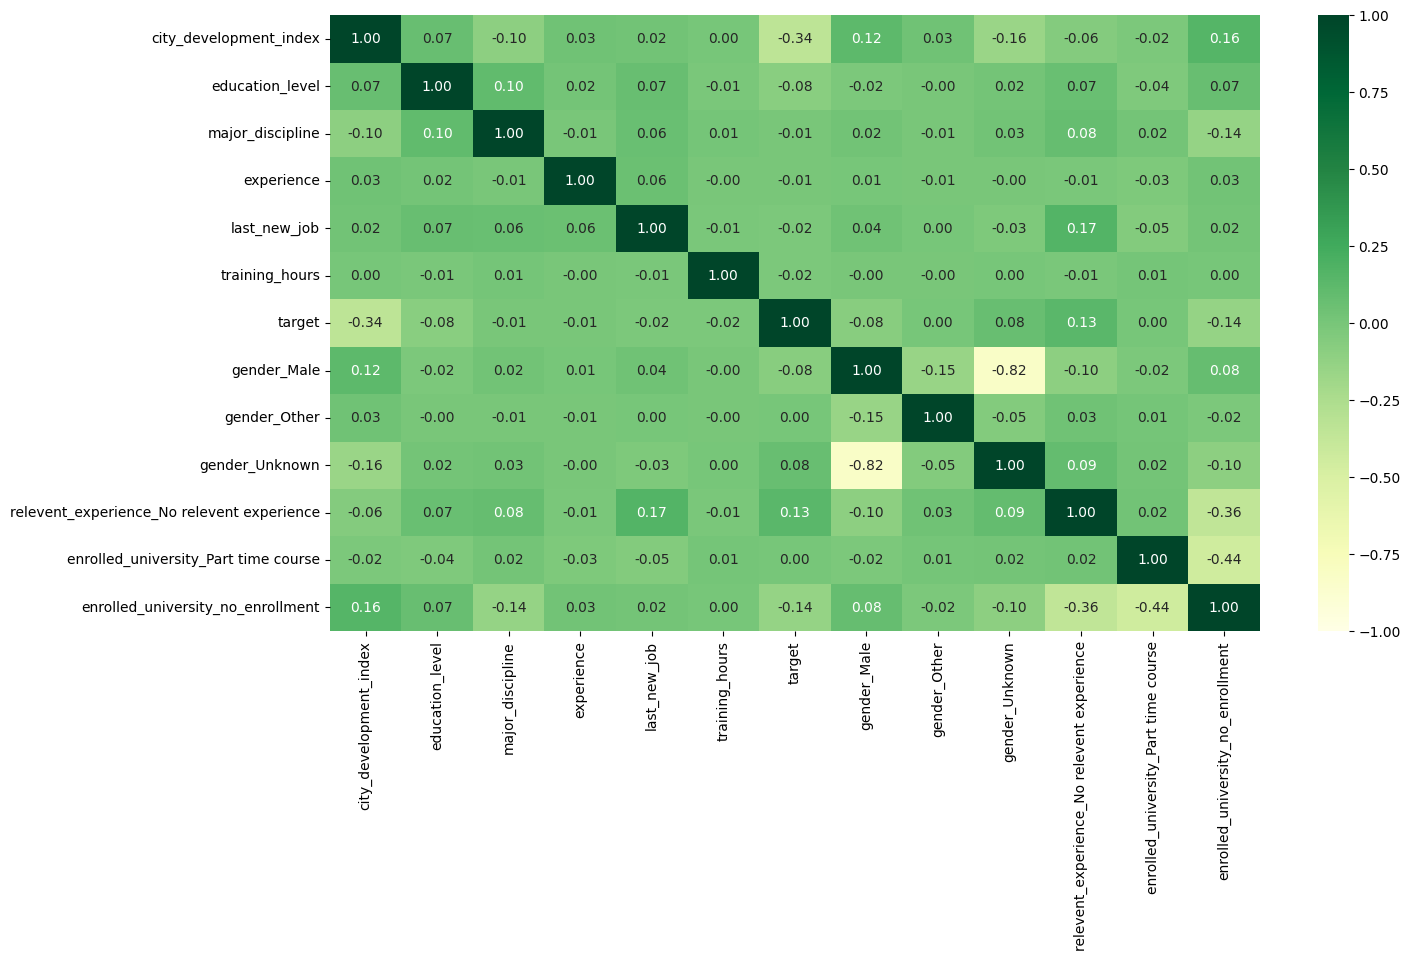

In [51]:
# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="YlGn")
plt.show()

### after the feature engineering we will start working on our model

## Model Evaluation
### Model evaluation criterion

### Model can make wrong predictions as:

Predicting a person will purchase a package and they do not purchase the package (False Positive)
Predicting a person will not purchase a package and they do purchase a package (False Negative)

### Which case is more important?

We want to avoid predicting that a person will not purchase a package and they would purchase a package as this would result in a missed opportunity.

### How to reduce this loss i.e need to reduce False Negatives?

Recall should be maximized, the greater the recall the higher the chances of minimizing false negatives.

In [52]:
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score, accuracy_score

In [53]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [54]:
resultsDict = {
    'Model': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'Accuracy': [],
    'Overfit': []
}

In [55]:
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model, save: bool, modelName, flag=True):
    '''
    model : classifier to predict values of X

    '''
    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    #Accuracy of the model
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    #Recall of the model
    train_recall = recall_score(y_train, pred_train)
    test_recall = recall_score(y_test, pred_test)
    
    #Precision of the model
    train_precision = precision_score(y_train, pred_train)
    test_precision = precision_score(y_test, pred_test)

    train_f1 = f1_score(y_train, pred_train)
    test_f1 = f1_score(y_test, pred_test)

    overfit = train_f1 - test_f1
    
    df_perf = pd.DataFrame(
        {
            "Precision": test_precision,
            "Recall": test_recall,
            "F1 Score": test_f1,
            "Accuracy": test_acc,
            "Overfit": overfit
        },
        index=[0],
    )
    
    # Storing results 
    if save == True:
        resultsDict['Model'].append(modelName)
        resultsDict['Precision'].append(test_precision)
        resultsDict['Recall'].append(test_recall)
        resultsDict['F1 Score'].append(test_f1)
        resultsDict['Accuracy'].append(test_acc)
        resultsDict['Overfit'].append(overfit)
        
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True: 
        print("Accuracy on training set : ", round(train_acc, 3))
        print("Accuracy on test set : ", round(test_acc, 3))
        print("Recall on training set : ", round(train_recall, 3))
        print("Recall on test set : ", round(test_recall, 3))
        print("Precision on training set : ", round(train_precision, 3))
        print("Precision on test set : ", round(test_precision, 3))
        print("F1 on training set : ", round(train_f1, 3))
        print("F1 on test set : ", round(test_f1, 3))
        print("Overfit : ", round(overfit, 3))

    return df_perf

In [56]:
def saveResults(model, pred, target, modelName, save: bool):
    
    # predicting using the independent variables
    precision = precision_score(target, pred)
    recall = recall_score(target, pred)
    f1 = f1_score(target, pred)
    accuracy = accuracy_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Accuracy": accuracy
        },
        index=[0],
    )
    
    # Storing results 
    if save == True:
        resultsDict['Model'].append(modelName)
        resultsDict['Precision'].append(precision)
        resultsDict['Recall'].append(recall)
        resultsDict['F1 Score'].append(f1)
        resultsDict['Accuracy'].append(accuracy)    

    return df_perf

## Split the data into train and test sets

In [57]:
X = df.drop("target" , axis=1)
y = df.pop("target")

In [58]:
# random state helps in repeating use of model, stratify is to preserve frequencies as much as possible bt test/train.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1,stratify=y)

## Bagging Models
### Building the bagging models

 - build these models with default parameters. Later we can use hyperparameter tuning to optimize model performance.
 - We will calculate Accuracy, Precision and Recall.  
 - Recall gives the ratio of True positives to Actual positives, so high Recall implies low false negatives, i.e. low chances of predicting a candidate as a non candidate

### Bagging Estimator

In [59]:
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(X_train,y_train)

BaggingClassifier(random_state=1)

In [60]:
bagging_estimator_score=get_metrics_score(bagging_estimator, True, "Bagging Estimator")

Accuracy on training set :  0.971
Accuracy on test set :  0.744
Recall on training set :  0.899
Recall on test set :  0.316
Precision on training set :  0.982
Precision on test set :  0.481
F1 on training set :  0.939
F1 on test set :  0.381
Overfit :  0.557


<b>Observations:</b>
- Precision and Recall both individually poor, as is accuracy.
- All three metrics much lower in test than training set, indicating overfit.
- Struggles especially hard with Recall

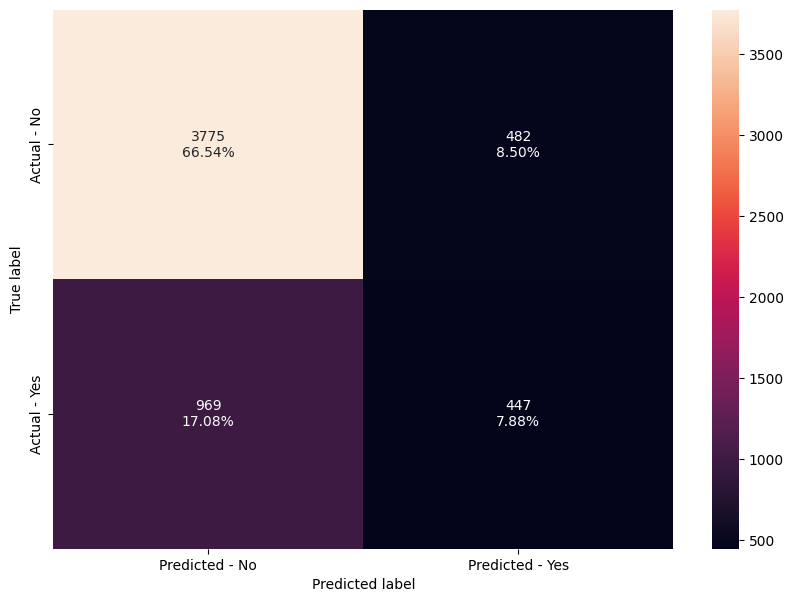

In [61]:
make_confusion_matrix(bagging_estimator,y_test)

### provide comments describing your confusion matrix results

<b>Observations:</b>
- Struggles the most with false negatives, which is not ideal.
- Does the best with true negatives.

## Hyperparameter Tuning
### Bagging Classifier
Some of the important hyperparameters available for bagging classifier are:
 - base_estimator: The base estimator to fit on random subsets of the dataset. If None(default), then the base estimator is a decision tree.
- n_estimators: The number of trees in the forest, default = 100.
- max_features: The number of features to consider when looking for the best split.
- bootstrap: Whether bootstrap samples are used when building trees. If False, the entire dataset is used to build each tree, default=True.
- bootstrap_features: If it is true, then features are drawn with replacement. Default value is False.
- max_samples: If bootstrap is True, then the number of samples to draw from X to train each base estimator. If None (default), then draw N samples, where N is the number of observations in the train data.
- oob_score: Whether to use out-of-bag samples to estimate the generalization accuracy, default=False.

In [62]:
# Specify the type of classifier. 
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of available parameters to choose from

parameters = {'max_samples': [0.7,0.8,0.9,1], 
              'max_features': [0.7,0.8,0.9,1],
              'n_estimators' : [10,20,30,40,50],
             }

# Scoring type used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search model
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the training data.
bagging_estimator_tuned.fit(X_train, y_train)

BaggingClassifier(max_features=0.7, max_samples=0.8, random_state=1)

In [63]:
# Calcuate metrics with defined function to get accuracy, recall and precision on train and test set using the 
# bagging classifier with best hyperparameters
bagging_estimator_tuned_score=get_metrics_score(bagging_estimator_tuned, True, "Tuned Bagging Est.")

Accuracy on training set :  0.924
Accuracy on test set :  0.759
Recall on training set :  0.756
Recall on test set :  0.344
Precision on training set :  0.928
Precision on test set :  0.525
F1 on training set :  0.833
F1 on test set :  0.416
Overfit :  0.417


In [64]:
bagging_estimator_score

,Precision,Recall,F1 Score,Accuracy,Overfit
0,0.481163,0.315678,0.381237,0.744227,0.55741


<b>Observations:</b>
- Tuned scores are slightly improved in all metrics.
- Still not close to being satisfactory.
- Overfit sees significant improvement, because tuned training scores are much worse.

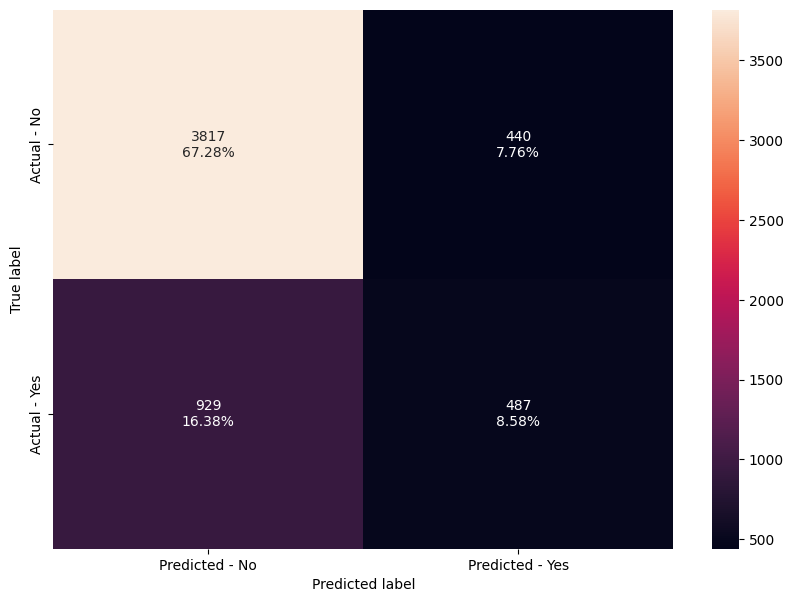

In [65]:
# produce confusion matrix
make_confusion_matrix(bagging_estimator_tuned,y_test)

<b>Observations:</b>
- Virtually no changes in the distributions on the confusion matrix.

In [66]:
# Change the base_estimator of the bagging classifier, which is a decision tree by default, to logistic regression
# for the bagging classifier. Note the solver is liblinear.
bagging_lr=BaggingClassifier(LogisticRegression(solver='liblinear',random_state=1,max_iter=1000),random_state=1)
bagging_lr.fit(X_train,y_train)

BaggingClassifier(estimator=LogisticRegression(max_iter=1000, random_state=1,
                                               solver='liblinear'),
                  random_state=1)

In [67]:
#Calculate accuracy, recall and precision on train and test set for the new model.
bagging_lr_score=get_metrics_score(bagging_lr, True, "Logistic Regression")

Accuracy on training set :  0.767
Accuracy on test set :  0.765
Recall on training set :  0.253
Recall on test set :  0.244
Precision on training set :  0.575
Precision on test set :  0.57
F1 on training set :  0.351
F1 on test set :  0.341
Overfit :  0.01


In [68]:
resultsDF = pd.DataFrame(resultsDict)
resultsDF

,Model,Precision,Recall,F1 Score,Accuracy,Overfit
0,Bagging Estimator,0.481163,0.315678,0.381237,0.744227,0.557410
1,Tuned Bagging Est.,0.525351,0.343927,0.415706,0.758681,0.417265
2,Logistic Regression,0.570248,0.243644,0.341415,0.765380,0.010067


<b>Observations:</b>
- Similar results to the bagging estimators, but with stronger precision, and worse recall.
- Virtually no statistical signs of overfit

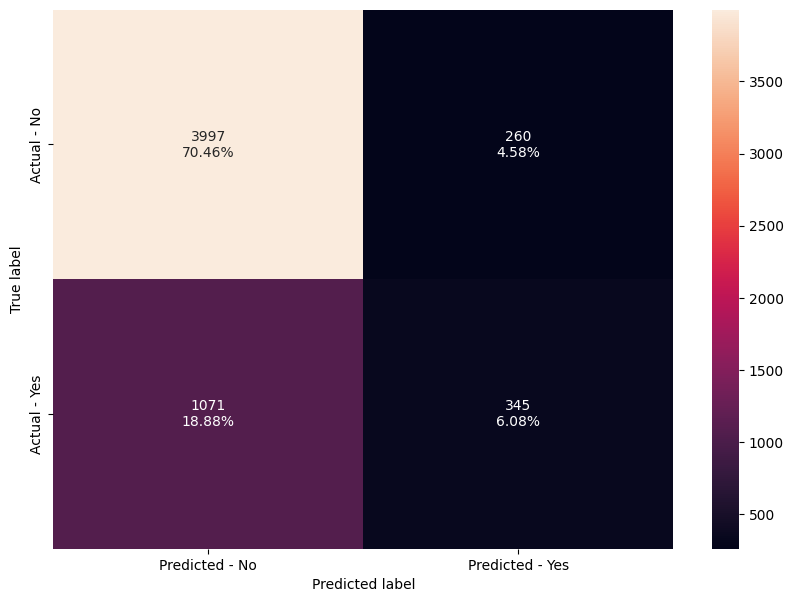

In [69]:
# Create confusion matrix
make_confusion_matrix(bagging_lr,y_test)

<b>Observations:</b>
- Also struggles particularly with false negatives.
- Struggles less with false positives than previous models.

## Random Forest

In [70]:
#Train the random forest classifier
rf_estimator=RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

RandomForestClassifier(random_state=1)

In [72]:
#Using previously defined function to get accuracy, recall and precision on train and test set
rf_estimator_score=get_metrics_score(rf_estimator, True, "Random Forest")

Accuracy on training set :  0.993
Accuracy on test set :  0.746
Recall on training set :  0.981
Recall on test set :  0.336
Precision on training set :  0.991
Precision on test set :  0.487
F1 on training set :  0.986
F1 on test set :  0.398
Overfit :  0.588


In [73]:
resultsDF = pd.DataFrame(resultsDict)
resultsDF

,Model,Precision,Recall,F1 Score,Accuracy,Overfit
0,Bagging Estimator,0.481163,0.315678,0.381237,0.744227,0.557410
1,Tuned Bagging Est.,0.525351,0.343927,0.415706,0.758681,0.417265
2,Logistic Regression,0.570248,0.243644,0.341415,0.765380,0.010067
3,Random Forest,0.487206,0.336158,0.397827,0.745990,0.588474


<b>Observations:</b>
- Worst, in terms of overfit, so far
- On par with untuned Bagging Estimator, in terms of precision and accuracy
- On par with tuned Bagging Estimator, in terms of recall

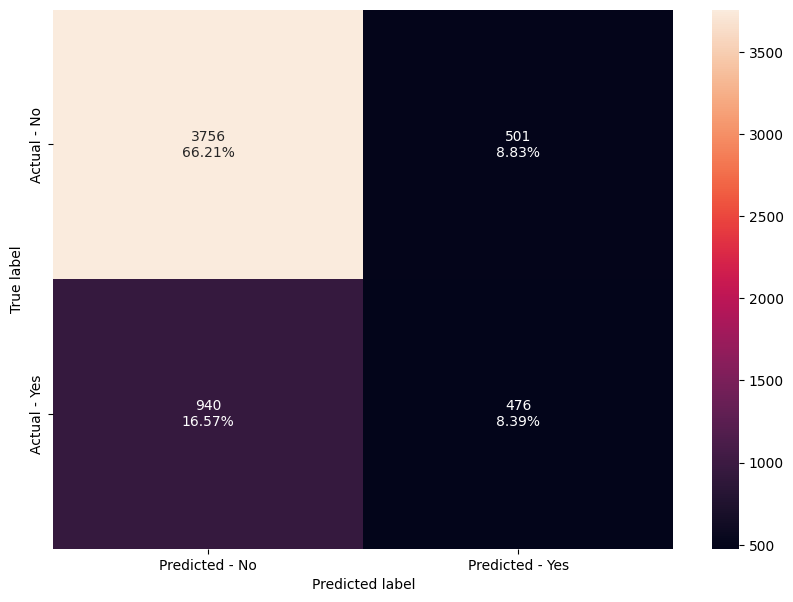

In [74]:
# Calculate confusion matrix
make_confusion_matrix(rf_estimator,y_test)

<b>Observation:</b>
- Struggles in false negatives the most, just like all other models thus far.

## Random Forest Classifier
Try to get a better model by tuning the random forest classifier. Some of the important hyperparameters available for random forest classifier are:
- n_estimators: The number of trees in the forest, default = 100.
- max_features: The number of features to consider when looking for the best split.
- class_weight: Weights associated with classes in the form {class_label: weight}.If not given, all classes are supposed to have weight one.
- For example: If the frequency of class 0 is 80% and the frequency of class 1 is 20% in the data, then class 0 will become the dominant class and the model will become biased toward the dominant classes. In this case, we can pass a dictionary {0:0.2,1:0.8} to the model to specify the weight of each class and the random forest will give more weightage to class 1.
- bootstrap: Whether bootstrap samples are used when building trees. If False, the entire dataset is used to build each tree, default=True.
- max_samples: If bootstrap is True, then the number of samples to draw from X to train each base estimator. If None (default), then draw N samples, where N is the number of observations in the train data.
- oob_score: Whether to use out-of-bag samples to estimate the generalization accuracy, default=False.
- Note: A lot of hyperparameters of Decision Trees are also available to tune Random Forest like max_depth, min_sample_split etc.

In [75]:
# Set the type of classifier. 
rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {"n_estimators": [150,200,250],
    "min_samples_leaf": np.arange(5, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
             }

# Specify scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer,cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(max_features=0.6000000000000001, max_samples=0.3,
                       min_samples_leaf=9, n_estimators=250, random_state=1)

In [76]:
# Using the previously defined function to get accuracy, recall and precision on train and test set
rf_estimator_tuned_score=get_metrics_score(rf_estimator_tuned, True, "Tuned Random Forest")

Accuracy on training set :  0.8
Accuracy on test set :  0.772
Recall on training set :  0.458
Recall on test set :  0.4
Precision on training set :  0.638
Precision on test set :  0.562
F1 on training set :  0.533
F1 on test set :  0.467
Overfit :  0.066


In [77]:
resultsDF = pd.DataFrame(resultsDict)
resultsDF

,Model,Precision,Recall,F1 Score,Accuracy,Overfit
0,Bagging Estimator,0.481163,0.315678,0.381237,0.744227,0.557410
1,Tuned Bagging Est.,0.525351,0.343927,0.415706,0.758681,0.417265
2,Logistic Regression,0.570248,0.243644,0.341415,0.765380,0.010067
3,Random Forest,0.487206,0.336158,0.397827,0.745990,0.588474
4,Tuned Random Forest,0.562066,0.399718,0.467189,0.772431,0.065697


<b>Observations:</b>
- Strongest in all categories, aside from overfit.
- Overfit also quite low, compared to other models, but still slightly higher than desirable
- Overall results are still quite weak, despite improvement

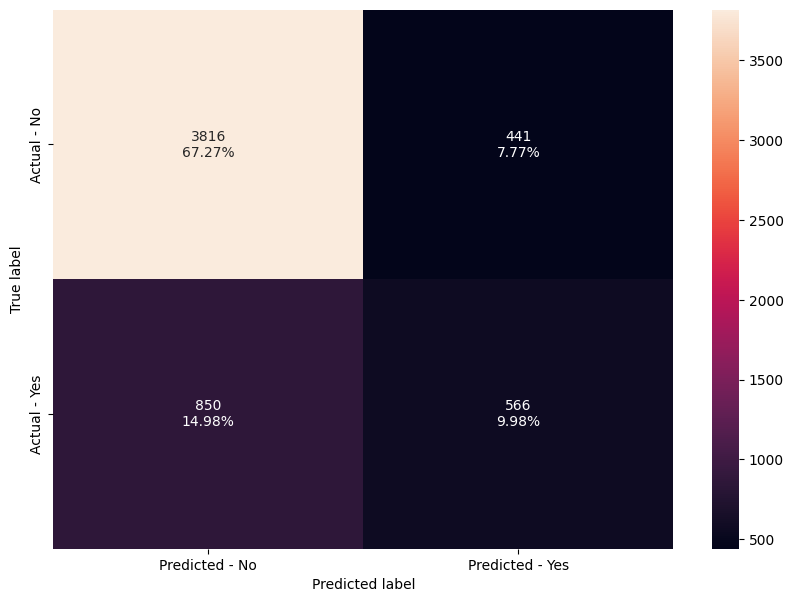

In [78]:
# Calculate confusion matrix
make_confusion_matrix(rf_estimator_tuned,y_test)

<b>Observation:<b>
- Still particularly struggles with false negatives

### Tune using class_weights for random forest:
The model performance can be stronger. 
We should make the model aware that the class of interest here is 'target'.
We can do so by passing the parameter class_weights available for random forest. This parameter is not available for the bagging classifier.
class_weight specifies the weights associated with classes in the form {class_label: weight}. If not given, all classes are supposed to have weight one.
We can choose class_weights={0:0.3,1:0.7} because that is the original imbalance in our data.

In [79]:
# Choose the type of classifier. 
rf_estimator_weighted = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "class_weight": [{0: 0.3, 1: 0.7}],
    "n_estimators": [100,150,200,250],
    "min_samples_leaf": np.arange(5, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_weighted, parameters, scoring=acc_scorer,cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_weighted = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_weighted.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.3, 1: 0.7},
                       max_features=0.5000000000000001,
                       max_samples=0.6000000000000001, min_samples_leaf=9,
                       n_estimators=150, random_state=1)

In [80]:
#Using previously defined function to get accuracy, recall and precision on train and test set
rf_estimator_weighted_score=get_metrics_score(rf_estimator_weighted, True, "Weighted Random Forest")

Accuracy on training set :  0.8
Accuracy on test set :  0.768
Recall on training set :  0.619
Recall on test set :  0.554
Precision on training set :  0.595
Precision on test set :  0.533
F1 on training set :  0.607
F1 on test set :  0.543
Overfit :  0.063


In [82]:
resultsDF = pd.DataFrame(resultsDict)
resultsDF

,Model,Precision,Recall,F1 Score,Accuracy,Overfit
0,Bagging Estimator,0.481163,0.315678,0.381237,0.744227,0.557410
1,Tuned Bagging Est.,0.525351,0.343927,0.415706,0.758681,0.417265
2,Logistic Regression,0.570248,0.243644,0.341415,0.765380,0.010067
3,Random Forest,0.487206,0.336158,0.397827,0.745990,0.588474
4,Tuned Random Forest,0.562066,0.399718,0.467189,0.772431,0.065697
5,Weighted Random Forest,0.533333,0.553672,0.543313,0.767671,0.063216


<b>Observations:</b>
- Model is notably weaker in precision, slightly weaker in accuracy.
- Model is significantly stronger in recall, and f1 score.
- Very similar overfit to tuned rf.

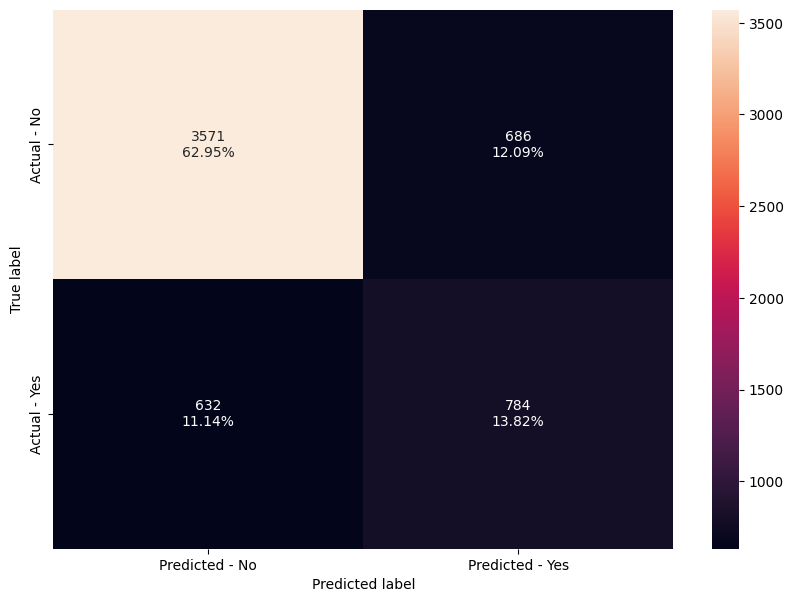

In [83]:
# Calculate the confusion matrix
make_confusion_matrix(rf_estimator_weighted,y_test)

<b>Observations:</b>
- Much stronger performance in false negatives.
- Much weaker performance in false positives.

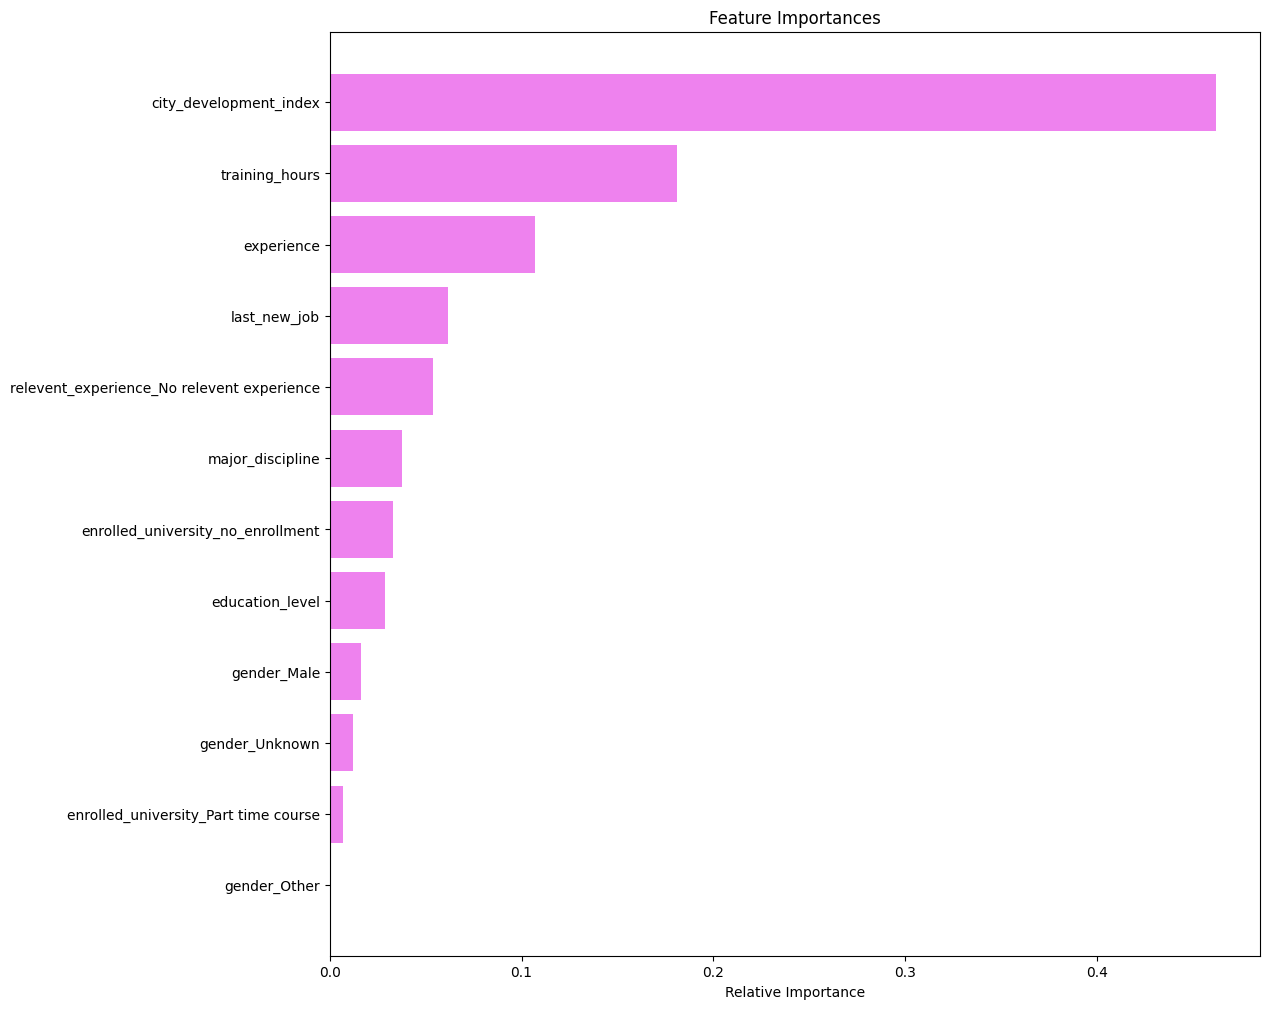

In [84]:
# check feature importance
importances = rf_estimator_weighted.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [87]:
# Create and display the frame of results
resultsDF = pd.DataFrame(resultsDict)
resultsDF

,Model,Precision,Recall,F1 Score,Accuracy,Overfit
0,Bagging Estimator,0.481163,0.315678,0.381237,0.744227,0.557410
1,Tuned Bagging Est.,0.525351,0.343927,0.415706,0.758681,0.417265
2,Logistic Regression,0.570248,0.243644,0.341415,0.765380,0.010067
3,Random Forest,0.487206,0.336158,0.397827,0.745990,0.588474
4,Tuned Random Forest,0.562066,0.399718,0.467189,0.772431,0.065697
5,Weighted Random Forest,0.533333,0.553672,0.543313,0.767671,0.063216


### Insights and conclusions

- Tuning through GridSearch gives slightly better results on average, but requires more in-depth and careful tuning.
- Hard-coding class weights is likely not a very helpful way of utilizing this parameter; iterating through a range of weights, and taking the combination with the best results is likely more efficient.
- Random Forest appears to be the most responsive to hyperparameter tuning (this was observed in previous assignments as well)
- Given all models' struggles with overfit, trying SVM might be a good idea for this dataset.